# Monte Carlo Simulations for Portfolio Analysis

## What are Monte Carlo Simulations?
Monte Carlo simulations are computational algorithms that rely on repeated random sampling to obtain numerical results. 
They are particularly useful for modeling systems with significant uncertainty and where analytical solutions are difficult or impossible to obtain.

## Applications in Finance
In finance, Monte Carlo methods are widely used to:
- Evaluate investment strategies
- Assess risk in portfolios
- Estimate the probability of different outcomes
- Price complex financial instruments
- Model future stock prices and returns

## This Notebook
This notebook uses my montecarlo module to do the following:
- We fetch historical price data from Yahoo Finance
- Calculate log returns and their statistical properties
- Simulate thousands of possible future price paths
- Analyze the distribution of potential outcomes
- Calculate risk metrics like Conditional Value at Risk (CVaR)

The primary class `NaiveMonteCarlo` allows you to simulate potential returns for a portfolio of stocks, visualize the results, and extract meaningful risk metrics to inform investment decisions.

Note that `NaiveMonteCarlo` is naive in that it assumes a multivariate normal destribution over log returns. It also has a alpha_correction parameter (not used in this notebook) to pump up or down the means according to your expectation of some alpha asymetry that you might have due to your knowledge of a company or market psychology (I will expand on that in another notebook). 

In [1]:
import sys
sys.path.append("../")
from wallstreet_quant.montecarlo import NaiveMonteCarlo


Summary Statistics:
Mean daily log returns: [0.00072279 0.00120909 0.00091081 0.00126368]
Daily volatilities: [0.00873247 0.01069738 0.00743904 0.00726488]
Data points: 249

Running Monte Carlo simulation...

Simulation Results Summary:
Mean return: 10.86%
Standard deviation: 7.43%
5th percentile (VaR): -0.92%
Probability of positive return: 93.4%


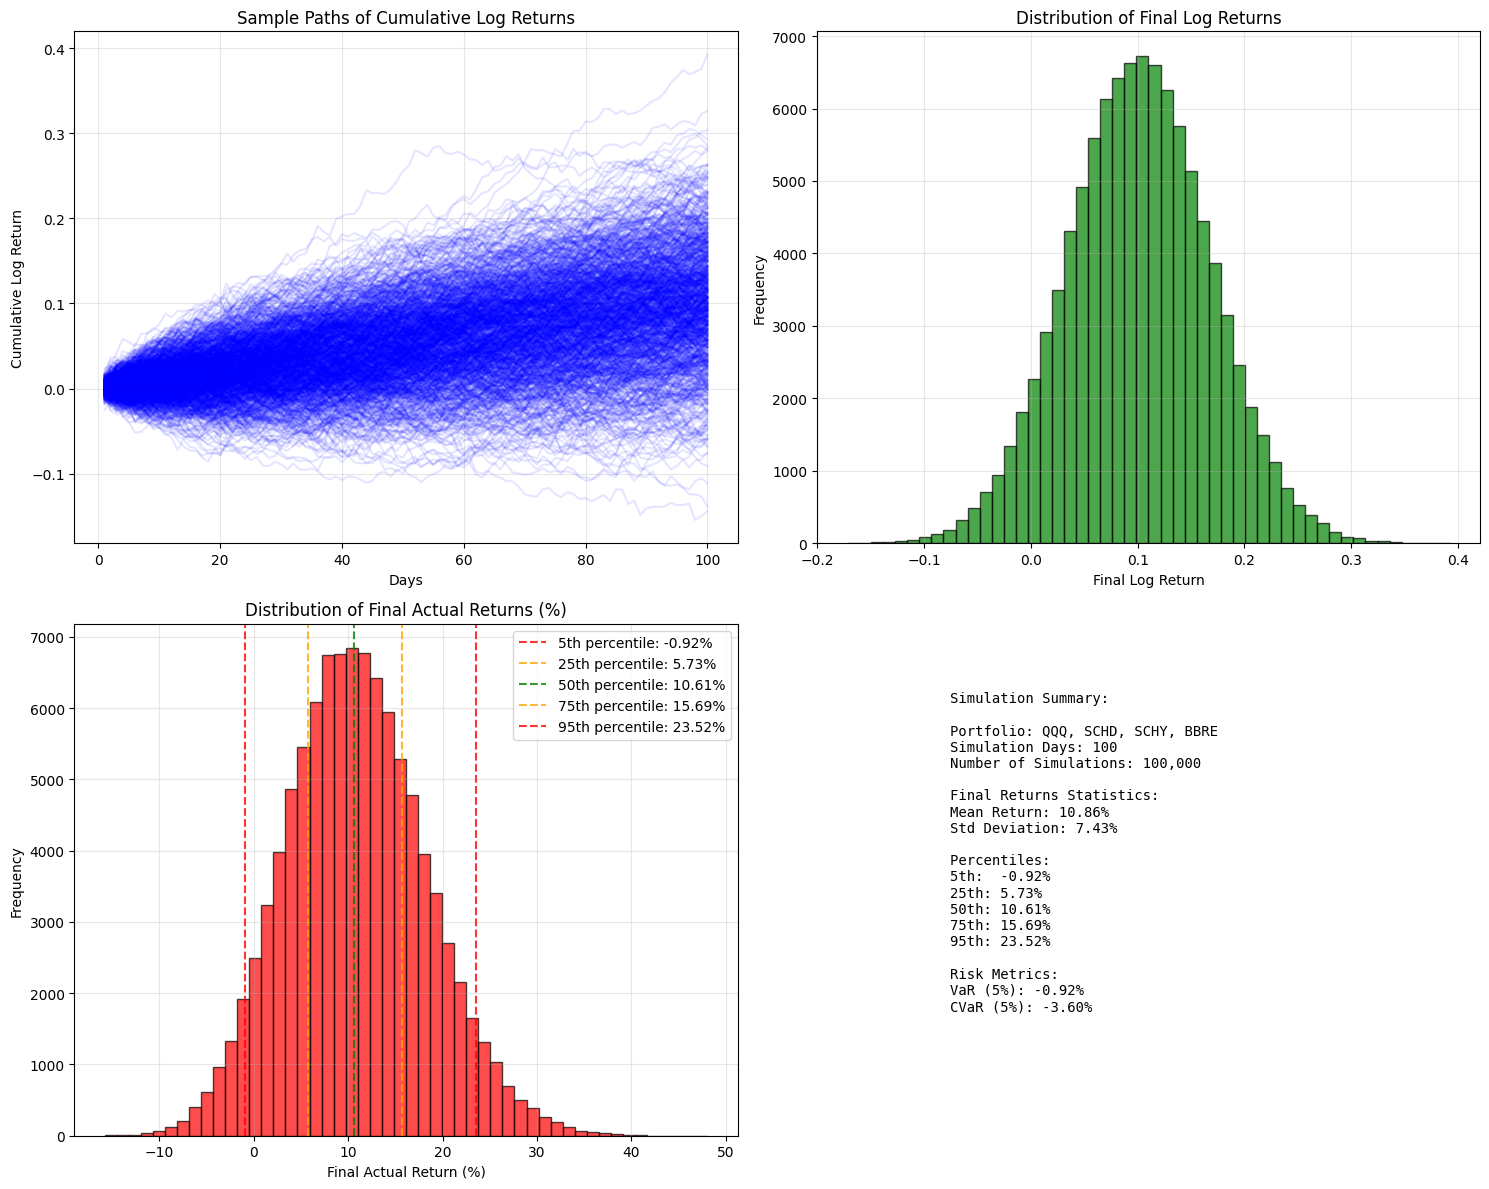

In [6]:
# Example with a few tech stocks
tickers = ['QQQ', 'SCHD', 'SCHY', 'BBRE']

alpha_correction = [0.0]*len(tickers)  # Adjusted returns for our alpha knowledge

# Equal weights across all tickers (must sum to 1.0)
weights = [0.2, 0.27, 0.23, 0.1]
weights = [w / sum(weights) for w in weights]  # Normalize weights to sum to 1.0
# Create Monte Carlo simulator
mc = NaiveMonteCarlo(tickers, alpha_correction=alpha_correction, weights=weights)

# Display summary statistics
stats = mc.get_summary_stats()
print("\nSummary Statistics:")
print(f"Mean daily log returns: {stats['mean_returns']}")
print(f"Daily volatilities: {stats['volatility']}")
print(f"Data points: {stats['data_points']}")

# Run Monte Carlo simulation
print("\nRunning Monte Carlo simulation...")
results = mc.run_simulation(days=100, n_simulations=100000)  # 100 days simulation

# Display results summary
summary = mc.get_simulation_summary()
print("\nSimulation Results Summary:")
print(f"Mean return: {summary['mean_return_pct']:.2f}%")
print(f"Standard deviation: {summary['std_return_pct']:.2f}%")
print(f"5th percentile (VaR): {summary['var_5_pct']:.2f}%")
print(f"Probability of positive return: {summary['probability_positive']:.1f}%")

# Plot results
mc.plot_results(show_percentiles=True)